# Anomalib 02_folder.ipynb 실행

### 경로 : examples/notebooks/02_data/datamodules/folder.ipynb

### 데이터셋 경로 지정

In [1]:
from pathlib import Path

# NOTE: Provide the path to the dataset root directory.
#   If the datasets is not downloaded, it will be downloaded
#   to this directory.
dataset_root = Path.cwd()/ "bolt"

### API를 통해 Folder Dataset(사용자 정의 데이터셋) 사용하기

- 여기서는 사용자가 직접 만든(custom) 데이터셋을 사용하여 anomalib 모델을 학습시키는 방법을 설명합니다.

In [2]:
# flake8: noqa
import numpy as np
from PIL import Image
from torchvision.transforms.v2.functional import to_pil_image

from anomalib.data import Folder, FolderDataset

W0521 09:24:49.640000 51208 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


### 데이터셋 정보 지정 코드

In [3]:
Folder??

Init signature:
Folder(
    name: str,
    normal_dir: str | pathlib.Path | collections.abc.Sequence[str | pathlib.Path],
    root: str | pathlib.Path | None = None,
    abnormal_dir: str | pathlib.Path | collections.abc.Sequence[str | pathlib.Path] | None = None,
    normal_test_dir: str | pathlib.Path | collections.abc.Sequence[str | pathlib.Path] | None = None,
    mask_dir: str | pathlib.Path | collections.abc.Sequence[str | pathlib.Path] | None = None,
    normal_split_ratio: float = 0.2,
    extensions: tuple[str] | None = None,
    train_batch_size: int = 32,
    eval_batch_size: int = 32,
    num_workers: int = 8,
    train_augmentations: torchvision.transforms.v2._transform.Transform | None = None,
    val_augmentations: torchvision.transforms.v2._transform.Transform | None = None,
    test_augmentations: torchvision.transforms.v2._transform.Transform | None = None,
    augmentations: torchvision.transforms.v2._transform.Transform | None = None,
    test_split_mode: anomalib.d

In [4]:
folder_datamodule = Folder(
    name="bolt",
    root=dataset_root,
    normal_dir="OK",
    abnormal_dir="NG",
    test_split_ratio = 0.2,
    seed = 42
)
folder_datamodule.setup()

In [5]:
# Train images
data = next(iter(folder_datamodule.train_data))
print(data.image.shape)

torch.Size([3, 1068, 712])


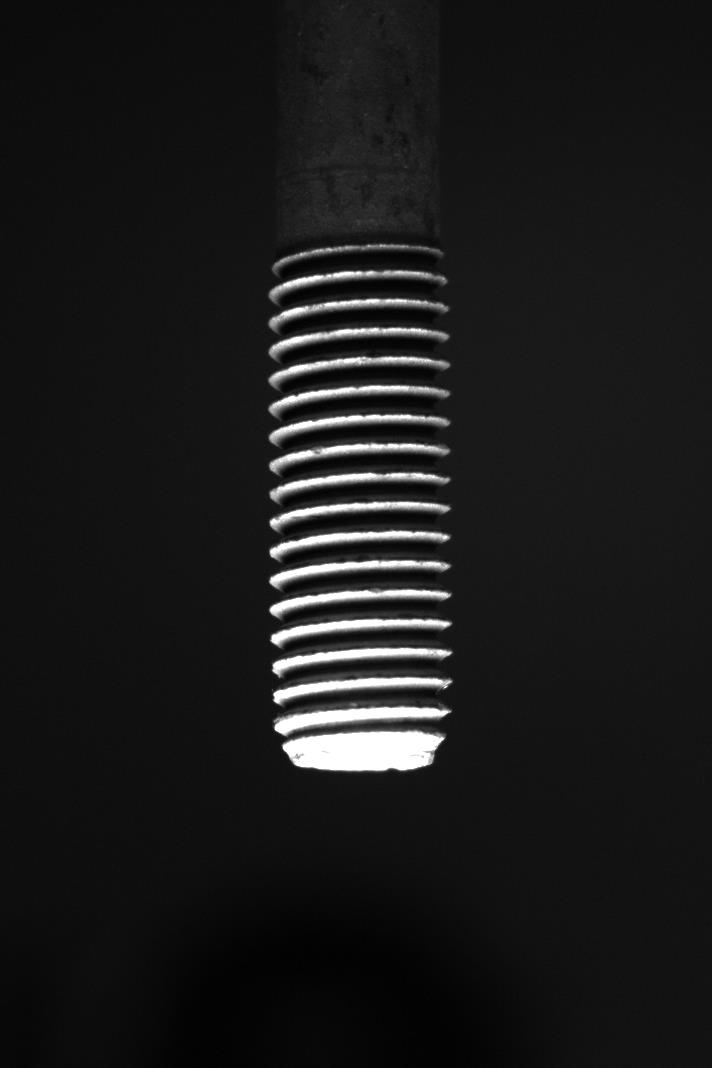

In [6]:
# 정상 이미지
img = to_pil_image(data.image.clone())

img

In [7]:
# Test images
data = next(iter(folder_datamodule.test_data))
print(data.image.shape)

torch.Size([3, 1280, 1024])


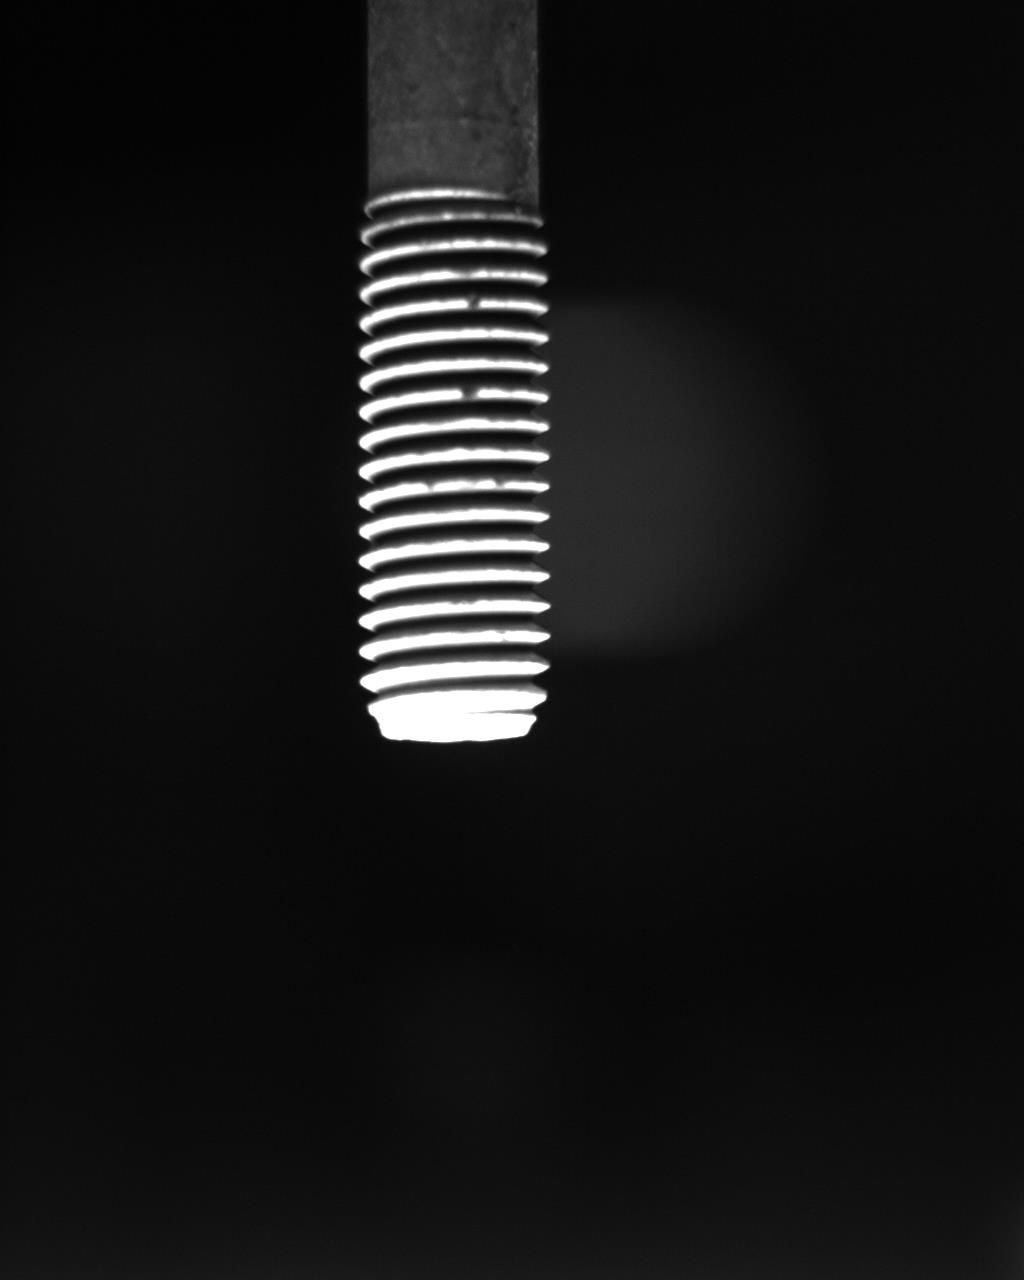

In [8]:
# 이상 이미지
img = to_pil_image(data.image.clone())

img